# Micrograd

##### This notebook is based on [this video](https://www.youtube.com/watch?v=VMj-3S1tku0)
Here we are going to recreate autograd in Python. It's not a production-ready version, it's just an example for education.
If you want to see graph pictures, you need to install graphviz like this:
`sudo apt install graphviz`

### Imports

In [7]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

### Gradient

In [8]:
def f(x):
    return 3*x**2 - 4*x + 5

In [9]:
f(3.0)

20.0

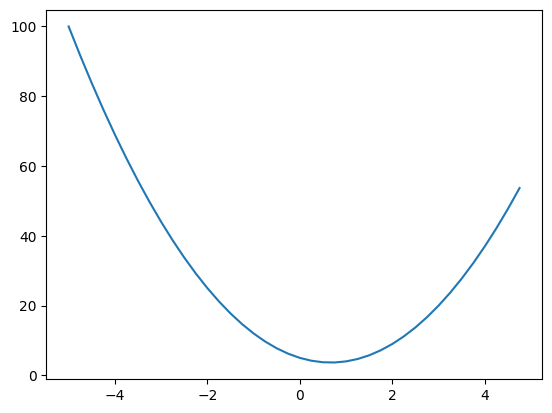

In [10]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

The given function is quadratic, so we can find global minimum (or maximum) by finding where the derivative equals zero.
$$f(x)= 3x^2−4x+5$$
$$f'(x) = 6x - 4$$
Setting the derivative to zero:
$$6x - 4 = 0 => x = 2/3$$
The leading coefficient is positive (a = 3 > 0), the parabola opens upward, confirming this is a
global minimum.

Let's find gradient of this function in different points. For doing this, we need to add a small number to x and check how result of function changes.

In [11]:
def dfdx_num(x):
    h = 0.00001
    return (f(x+h) - f(x))/h

def dfdx_math(x):
    return 6*x - 4

These two functions should give the same result. The smaller h, the closer results we get

In [16]:
x = 3.0
x, f(x), dfdx_num(x), dfdx_math(x)  # gradient is positive, x increases -> f(x) increases too

(3.0, 20.0, 14.00003000000538, 14.0)

In [17]:
x = 2/3
x, f(x), dfdx_num(x), dfdx_math(x) # gradient is zero, increasing x by small number doesn't give a lot of impact to f(x)

(0.6666666666666666, 3.666666666666667, 3.0000002482211127e-05, 0.0)

In [18]:
x = -2
x, f(x), dfdx_num(x), dfdx_math(x) # gradient is negative, x increases -> f(x) decreases

(-2, 25, -15.999970000279971, -16)

### Value class

Now, let's create a class which contains all needed information, so we can run backward function which will find gradients for all variables. We are going to use [**chain rule**](https://en.wikipedia.org/wiki/Chain_rule), it says that we should multiply local derivative by outter derivative. For example, we have variable `x` and two functions `y` and `z`. Composition of these functions looks like this:
$$ z(y(x)) $$
The derivative of `z` function w.r.t `x` is:
$$ \frac{dz}{dx} = \frac{dz}{dy} * \frac{dy}{dx} $$

In [96]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other, label=f'{other}')
        out = Value(self.data + other.data, (self, other), '+', f'{self.label}+{other.label}')
        def _backward():
            self.grad += 1.0 * out.grad # local gradient is 1
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other, label=f'{other}')
        out = Value(self.data * other.data, (self, other), '*', f'{self.label}*{other.label}')
        def _backward():
            self.grad += other.data * out.grad # local gradient of self is other.data
            other.grad += self.data * out.grad # local gradient of other is self.data
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}', f'{self.label}**{other}')
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        return (-self) + other

    def __truediv__(self, other):
        return self * other**-1

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad # derivative of tanh: (1 - tanh(x)^2)
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
    

### Draw graph

In [20]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid+n._op, label=n._op)
            dot.edge(uid+n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

### Example a*b + c*d

In [26]:
a = Value(4.0, label='a')
b = Value(3.0, label='b')
c = Value(-5.0, label='c')
d = Value(2.0, label='d')
o = a*b + c*d
o.backward()

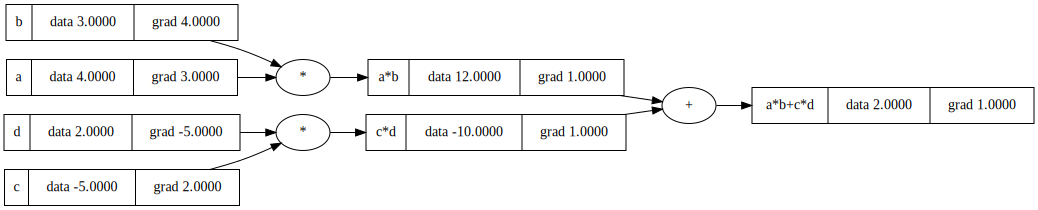

In [27]:
draw_dot(o)

### Examples of diffrent operations

In [86]:
a = Value(4.0, label='a')
b = Value(2.0, label='b')
a + 1

Value(data=5.0)

In [33]:
1 + a

Value(data=5.0)

In [34]:
a * 2

Value(data=8.0)

In [38]:
2 * a

Value(data=8.0)

In [45]:
-a

Value(data=-4.0)

In [47]:
b - a

Value(data=-2.0)

In [48]:
a - 1

Value(data=3.0)

In [56]:
1 - a

Value(data=-3.0)

In [57]:
-1 - a

Value(data=-5.0)

In [65]:
Value(1).tanh()

Value(data=0.7615941559557649)

In [66]:
Value(-0.5).tanh()

Value(data=-0.46211715726000974)

In [67]:
Value(0).tanh()

Value(data=0.0)

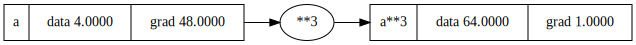

In [87]:
a = Value(4.0, label='a')
d = a**3
d.backward()
draw_dot(d)

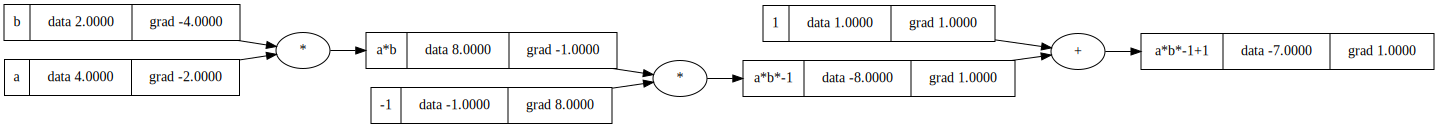

In [93]:
a = Value(4.0, label='a')
b = Value(2.0, label='b')
d = 1 - (a * b)
d.backward()
draw_dot(d)

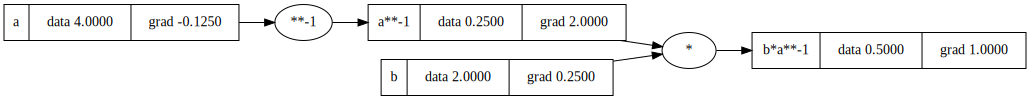

In [97]:
a = Value(4.0, label='a')
b = Value(2.0, label='b')
d = b/a
d.backward()
draw_dot(d)

### Neuron example

In [168]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
n = x1*w1 + x2*w2 + b
o = n.tanh(); o.label = 'o'
o.backward()

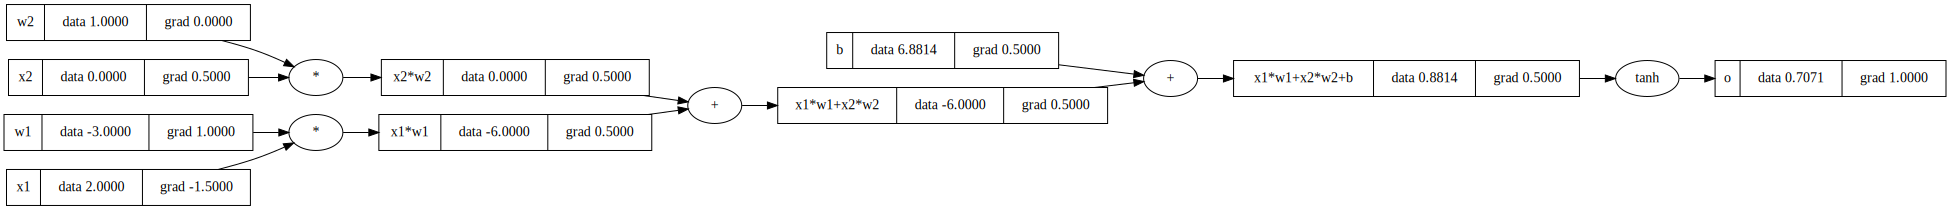

In [169]:
draw_dot(o)

Let's check gradients

In [101]:
import torch

In [102]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


### Neuron class

In [148]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1), label=f'w{i+1}') for i in range(nin)]
        self.b = Value(random.uniform(-1, 1), label='b')

    def __call__(self, x):
        # w * x + b
        mul = []
        for wi, xi in zip(self.w, x):
            wixi = wi*xi; wixi.label = wi.label + 'x'
            mul.append(wixi)
        act = sum(mul, self.b)
        out = act.tanh()
        return out

    def __repr__(self):
        return f"Neuron({len(self.w)})"

    def parameters(self):
        return self.w + [self.b]

In [149]:
n = Neuron(3)
n([1, 2, 3])

Value(data=-0.03460876802629538)

In [150]:
n.parameters()

[Value(data=0.8328866693208117),
 Value(data=-0.9193187188983301),
 Value(data=0.009864824634302716),
 Value(data=0.9415336988631555)]

### Layer class

In [151]:
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

In [152]:
L = Layer(3, 4)
L([1, 2, 3])

[Value(data=-0.563432442605019),
 Value(data=0.14727040464313698),
 Value(data=-0.2630128788865215),
 Value(data=0.859674749348512)]

In [153]:
L.parameters()

[Value(data=-0.2649812056633556),
 Value(data=0.12249150071194026),
 Value(data=-0.29745794753691834),
 Value(data=0.274524130391663),
 Value(data=-0.6440128044342508),
 Value(data=-0.5663948576869886),
 Value(data=0.7888523516110904),
 Value(data=-0.4414053620992884),
 Value(data=0.18329620027445803),
 Value(data=-0.7981575307750477),
 Value(data=0.2673273142824881),
 Value(data=0.34169446739521914),
 Value(data=-0.3317372482076437),
 Value(data=-0.37776705538600885),
 Value(data=0.7009526762498337),
 Value(data=0.27651029944361083)]

### MLP (multilayer perceptron) class

In [161]:
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def __repr__(self):
        return f"MLP of [\n{'\n'.join(str(layer) for layer in self.layers)}]"

    def parameters(self):
        return [p for l in self.layers for p in l.parameters()]

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0.0

In [162]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n

MLP of [
Layer of [Neuron(3), Neuron(3), Neuron(3), Neuron(3)]
Layer of [Neuron(4), Neuron(4), Neuron(4), Neuron(4)]
Layer of [Neuron(4)]]

In [158]:
o = n(x)
o.backward()

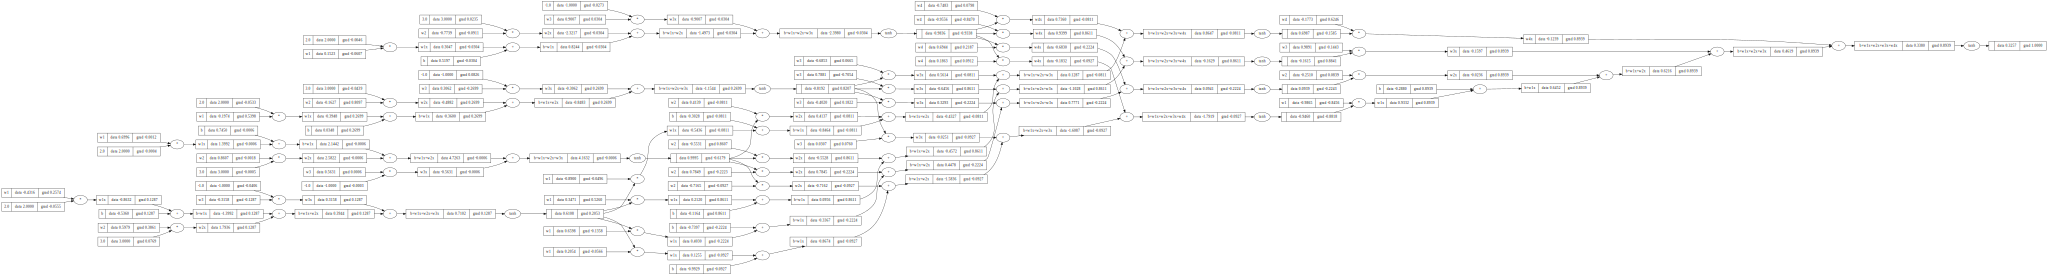

In [159]:
draw_dot(o)

In [164]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]
n = MLP(3, [4, 4, 1])
for k in range(20):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward pass
    n.zero_grad()
    loss.backward()
    for p in n.parameters():
        p.data += -0.1 * p.grad

    print(k, loss.data)
    

0 7.518331653125006
1 1.9950059003198612
2 0.49679423062437766
3 0.1823811800149582
4 0.10138051692527913
5 0.07446915418244168
6 0.05892245028772975
7 0.048648000939908856
8 0.04134154706321412
9 0.035883336926025675
10 0.03165551957703873
11 0.028287847720297944
12 0.025544703215519982
13 0.023269000751560076
14 0.021352021112274494
15 0.019716161505955822
16 0.018304573306641033
17 0.01707467805002699
18 0.01599396801271474
19 0.01503720487350339


In [165]:
ypred

[Value(data=0.9454288555173629),
 Value(data=-0.954790818185974),
 Value(data=-0.9401164048072663),
 Value(data=0.9198172090167867)]